In [13]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [14]:
# ============================================================
# 2. SET RANDOM SEEDS
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [15]:
# ============================================================
# 3. LOAD IMDB DATASET
# ============================================================

max_features = 10000

(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(
    num_words=max_features
)

print("Training samples:", len(X_train_raw))
print("Testing samples :", len(X_test_raw))
print("First review length:", len(X_train_raw[0]))

Training samples: 25000
Testing samples : 25000
First review length: 218


In [16]:
# ============================================================
# 4. CHECK LABEL DISTRIBUTION
# ============================================================

print("\nTraining label distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting label distribution:")
print(pd.Series(y_test).value_counts())


Training label distribution:
1    12500
0    12500
Name: count, dtype: int64

Testing label distribution:
0    12500
1    12500
Name: count, dtype: int64


In [17]:
# ============================================================
# 5. CREATE A FIXED TRAIN / VALIDATION SPLIT
# ============================================================
# IMPORTANT:
# We create ONE validation split and use the exact same split
# for every experiment.
#
# This makes the comparison between models fair.
# ============================================================

X_train_seq, X_val_seq, y_train_final, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

print("Training samples  :", len(X_train_seq))
print("Validation samples:", len(X_val_seq))
print("Test samples      :", len(X_test_raw))

Training samples  : 20000
Validation samples: 5000
Test samples      : 25000


In [18]:
# ============================================================
# 6. DEFINE ALL HYPERPARAMETER COMBINATIONS
# ============================================================

max_len_values = [250, 500]

rnn_units_values = [64, 128]

activation_values = ["relu", "tanh"]

dropout_values = [0.0, 0.2, 0.5]

total_experiments = (
    len(max_len_values)
    * len(rnn_units_values)
    * len(activation_values)
    * len(dropout_values)
)

print("Total experiments:", total_experiments)

Total experiments: 24


In [19]:
# ============================================================
# 7. MODEL CREATION FUNCTION
# ============================================================

def create_model(max_len, rnn_units, activation, dropout_rate):

    model = Sequential([
        tf.keras.Input(shape=(max_len,)),

        Embedding(
            input_dim=max_features,
            output_dim=128
        ),

        SimpleRNN(
            rnn_units,
            activation=activation
        ),

        Dropout(dropout_rate),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [20]:
# ============================================================
# 8. PREPARE DATA FOR EACH SEQUENCE LENGTH
# ============================================================

data = {}

for max_len in max_len_values:

    print(f"\nPreparing max_len = {max_len}")

    X_train_pad = pad_sequences(
        X_train_seq,
        maxlen=max_len
    )

    X_val_pad = pad_sequences(
        X_val_seq,
        maxlen=max_len
    )

    X_test_pad = pad_sequences(
        X_test_raw,
        maxlen=max_len
    )

    data[max_len] = {
        "X_train": X_train_pad,
        "X_val": X_val_pad,
        "X_test": X_test_pad
    }

    print("Train shape:", X_train_pad.shape)
    print("Val shape  :", X_val_pad.shape)
    print("Test shape :", X_test_pad.shape)


Preparing max_len = 250
Train shape: (20000, 250)
Val shape  : (5000, 250)
Test shape : (25000, 250)

Preparing max_len = 500
Train shape: (20000, 500)
Val shape  : (5000, 500)
Test shape : (25000, 500)


In [21]:
# ============================================================
# 9. RUN ALL EXPERIMENTS
# ============================================================

results = []

experiment_number = 0

for max_len in max_len_values:

    X_train_pad = data[max_len]["X_train"]
    X_val_pad = data[max_len]["X_val"]
    X_test_pad = data[max_len]["X_test"]

    for rnn_units in rnn_units_values:

        for activation in activation_values:

            for dropout_rate in dropout_values:

                experiment_number += 1

                print("\n")
                print("=" * 70)
                print(f"EXPERIMENT {experiment_number}/{total_experiments}")
                print("=" * 70)

                print("max_len   :", max_len)
                print("RNN units :", rnn_units)
                print("activation:", activation)
                print("dropout   :", dropout_rate)

                # Clear previous model from memory
                tf.keras.backend.clear_session()

                # Set seed again for reproducibility
                np.random.seed(SEED)
                tf.random.set_seed(SEED)

                # Create NEW model
                model = create_model(
                    max_len=max_len,
                    rnn_units=rnn_units,
                    activation=activation,
                    dropout_rate=dropout_rate
                )

                # ------------------------------------------------
                # CALLBACKS
                # ------------------------------------------------

                early_stopping = EarlyStopping(
                    monitor="val_loss",
                    patience=2,
                    restore_best_weights=True
                )

                reduce_lr = ReduceLROnPlateau(
                    monitor="val_loss",
                    factor=0.5,
                    patience=1,
                    min_lr=1e-6
                )

                # ------------------------------------------------
                # TRAIN
                # ------------------------------------------------

                history = model.fit(
                    X_train_pad,
                    y_train_final,
                    validation_data=(X_val_pad, y_val),
                    epochs=15,
                    batch_size=64,
                    callbacks=[
                        early_stopping,
                        reduce_lr
                    ],
                    verbose=1
                )

                # ------------------------------------------------
                # BEST VALIDATION RESULTS
                # ------------------------------------------------

                best_epoch = np.argmax(
                    history.history["val_accuracy"]
                ) + 1

                best_val_accuracy = max(
                    history.history["val_accuracy"]
                )

                best_val_loss = min(
                    history.history["val_loss"]
                )

                best_train_accuracy = (
                    history.history["accuracy"][best_epoch - 1]
                )

                train_accuracy_at_best = best_train_accuracy

                # ------------------------------------------------
                # TEST SET
                # ------------------------------------------------

                test_loss, test_accuracy = model.evaluate(
                    X_test_pad,
                    y_test,
                    verbose=0
                )

                # ------------------------------------------------
                # STORE RESULTS
                # ------------------------------------------------

                results.append({
                    "experiment": experiment_number,
                    "max_len": max_len,
                    "rnn_units": rnn_units,
                    "activation": activation,
                    "dropout": dropout_rate,
                    "best_epoch": best_epoch,
                    "train_accuracy": train_accuracy_at_best,
                    "val_accuracy": best_val_accuracy,
                    "val_loss": best_val_loss,
                    "test_accuracy": test_accuracy,
                    "test_loss": test_loss
                })

                print("\nRESULT")
                print("-" * 50)
                print(
                    f"Best Epoch     : {best_epoch}"
                )
                print(
                    f"Train Accuracy : {train_accuracy_at_best:.4f}"
                )
                print(
                    f"Val Accuracy   : {best_val_accuracy:.4f}"
                )
                print(
                    f"Val Loss       : {best_val_loss:.4f}"
                )
                print(
                    f"Test Accuracy  : {test_accuracy:.4f}"
                )
                print(
                    f"Test Loss      : {test_loss:.4f}"
                )



EXPERIMENT 1/24
max_len   : 250
RNN units : 64
activation: relu
dropout   : 0.0
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.6877 - loss: 0.5748 - val_accuracy: 0.8294 - val_loss: 0.4072 - learning_rate: 0.0010
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8297 - loss: 0.3856 - val_accuracy: 0.8274 - val_loss: 0.4086 - learning_rate: 0.0010
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8918 - loss: 0.2651 - val_accuracy: 0.8464 - val_loss: 0.3887 - learning_rate: 5.0000e-04
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9262 - loss: 0.1917 - val_accuracy: 0.8556 - val_loss: 0.4189 - learning_rate: 5.0000e-04
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9471 - loss: 0.1454 - val_accuracy: 0.8692 - val_loss: 0.3888 - learning_rate: 2.5000e-04

RESULT
--------------------------------------------------
Best Epoch     : 5
Train Accuracy : 0.9471
Val Accuracy   : 0.8692
Val Loss      

In [22]:
# ============================================================
# 10. RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

print("\nAll experiment results:")
display(results_df)


All experiment results:


,experiment,max_len,rnn_units,activation,dropout,best_epoch,train_accuracy,val_accuracy,val_loss,test_accuracy,test_loss
0,1,250,64,relu,0.0,5,0.94715,0.8692,0.388666,0.84784,0.374858
1,2,250,64,relu,0.2,5,0.95085,0.8544,0.381334,0.84284,0.377634
2,3,250,64,relu,0.5,5,0.91510,0.8348,0.430401,0.82020,0.441358
3,4,250,64,tanh,0.0,3,0.92745,0.8270,0.421870,0.81788,0.412176
4,5,250,64,tanh,0.2,1,0.68365,0.8178,0.418114,0.81660,0.416874
5,6,250,64,tanh,0.5,3,0.84570,0.8006,0.460470,0.80324,0.452063
6,7,250,128,relu,0.0,2,0.65855,0.6320,0.630738,0.63068,0.626096
7,8,250,128,relu,0.2,3,0.66740,0.6372,0.621141,0.61744,0.624417
8,9,250,128,relu,0.5,8,0.94135,0.8522,0.434217,0.83028,0.429701
9,10,250,128,tanh,0.0,6,0.92675,0.8406,0.420858,0.82940,0.416137


In [23]:
# ============================================================
# 11. SORT BY VALIDATION ACCURACY
# ============================================================

results_by_val = results_df.sort_values(
    by="val_accuracy",
    ascending=False
).reset_index(drop=True)

print("BEST MODELS BASED ON VALIDATION ACCURACY")
display(results_by_val)

BEST MODELS BASED ON VALIDATION ACCURACY


,experiment,max_len,rnn_units,activation,dropout,best_epoch,train_accuracy,val_accuracy,val_loss,test_accuracy,test_loss
0,1,250,64,relu,0.0,5,0.94715,0.8692,0.388666,0.84784,0.374858
1,2,250,64,relu,0.2,5,0.95085,0.8544,0.381334,0.84284,0.377634
2,9,250,128,relu,0.5,8,0.94135,0.8522,0.434217,0.83028,0.429701
3,10,250,128,tanh,0.0,6,0.92675,0.8406,0.420858,0.82940,0.416137
4,15,500,64,relu,0.5,5,0.90645,0.8406,0.433113,0.81824,0.429231
5,3,250,64,relu,0.5,5,0.91510,0.8348,0.430401,0.82020,0.441358
6,4,250,64,tanh,0.0,3,0.92745,0.8270,0.421870,0.81788,0.412176
7,12,250,128,tanh,0.5,4,0.86750,0.8250,0.434175,0.82848,0.423036
8,16,500,64,tanh,0.0,3,0.92280,0.8248,0.445624,0.80876,0.437152
9,23,500,128,tanh,0.2,5,0.89620,0.8248,0.440914,0.81576,0.433097


In [24]:
# ============================================================
# 12. TOP 10 MODELS
# ============================================================

top_10 = results_by_val.head(10)

display(top_10)

,experiment,max_len,rnn_units,activation,dropout,best_epoch,train_accuracy,val_accuracy,val_loss,test_accuracy,test_loss
0,1,250,64,relu,0.0,5,0.94715,0.8692,0.388666,0.84784,0.374858
1,2,250,64,relu,0.2,5,0.95085,0.8544,0.381334,0.84284,0.377634
2,9,250,128,relu,0.5,8,0.94135,0.8522,0.434217,0.83028,0.429701
3,10,250,128,tanh,0.0,6,0.92675,0.8406,0.420858,0.82940,0.416137
4,15,500,64,relu,0.5,5,0.90645,0.8406,0.433113,0.81824,0.429231
5,3,250,64,relu,0.5,5,0.91510,0.8348,0.430401,0.82020,0.441358
6,4,250,64,tanh,0.0,3,0.92745,0.8270,0.421870,0.81788,0.412176
7,12,250,128,tanh,0.5,4,0.86750,0.8250,0.434175,0.82848,0.423036
8,16,500,64,tanh,0.0,3,0.92280,0.8248,0.445624,0.80876,0.437152
9,23,500,128,tanh,0.2,5,0.89620,0.8248,0.440914,0.81576,0.433097


In [25]:
# ============================================================
# 13. BEST CONFIGURATION
# ============================================================

best_config = results_by_val.iloc[0]

print("BEST CONFIGURATION")
print("=" * 50)

print("max_len   :", best_config["max_len"])
print("RNN units :", best_config["rnn_units"])
print("activation:", best_config["activation"])
print("dropout   :", best_config["dropout"])

print("\nValidation accuracy:",
      f"{best_config['val_accuracy']:.4f}")

print("Validation loss:",
      f"{best_config['val_loss']:.4f}")

print("Test accuracy:",
      f"{best_config['test_accuracy']:.4f}")

print("Test loss:",
      f"{best_config['test_loss']:.4f}")

BEST CONFIGURATION
max_len   : 250
RNN units : 64
activation: relu
dropout   : 0.0

Validation accuracy: 0.8692
Validation loss: 0.3887
Test accuracy: 0.8478
Test loss: 0.3749


In [26]:
# ============================================================
# 14. SORT BY TEST ACCURACY
# ============================================================

results_by_test = results_df.sort_values(
    by="test_accuracy",
    ascending=False
).reset_index(drop=True)

print("MODELS SORTED BY TEST ACCURACY")
display(results_by_test)

MODELS SORTED BY TEST ACCURACY


,experiment,max_len,rnn_units,activation,dropout,best_epoch,train_accuracy,val_accuracy,val_loss,test_accuracy,test_loss
0,1,250,64,relu,0.0,5,0.94715,0.8692,0.388666,0.84784,0.374858
1,2,250,64,relu,0.2,5,0.95085,0.8544,0.381334,0.84284,0.377634
2,9,250,128,relu,0.5,8,0.94135,0.8522,0.434217,0.83028,0.429701
3,10,250,128,tanh,0.0,6,0.92675,0.8406,0.420858,0.82940,0.416137
4,12,250,128,tanh,0.5,4,0.86750,0.8250,0.434175,0.82848,0.423036
5,3,250,64,relu,0.5,5,0.91510,0.8348,0.430401,0.82020,0.441358
6,15,500,64,relu,0.5,5,0.90645,0.8406,0.433113,0.81824,0.429231
7,4,250,64,tanh,0.0,3,0.92745,0.8270,0.421870,0.81788,0.412176
8,19,500,128,relu,0.0,9,0.93805,0.8182,0.449644,0.81720,0.439229
9,22,500,128,tanh,0.0,4,0.85270,0.8128,0.432422,0.81688,0.422351


In [27]:
# ============================================================
# 15. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "simple_rnn_all_combinations.csv",
    index=False
)

print("Results saved to simple_rnn_all_combinations.csv")

Results saved to simple_rnn_all_combinations.csv


In [28]:
# ============================================================
# 16. ACTIVATION COMPARISON
# ============================================================

activation_summary = (
    results_df
    .groupby("activation")
    .agg(
        mean_val_accuracy=("val_accuracy", "mean"),
        best_val_accuracy=("val_accuracy", "max"),
        mean_test_accuracy=("test_accuracy", "mean"),
        best_test_accuracy=("test_accuracy", "max")
    )
    .reset_index()
)

display(activation_summary)

,activation,mean_val_accuracy,best_val_accuracy,mean_test_accuracy,best_test_accuracy
0,relu,0.778867,0.8692,0.767823,0.84784
1,tanh,0.802633,0.8406,0.797253,0.82940


In [29]:
# ============================================================
# 17. RNN UNIT COMPARISON
# ============================================================

units_summary = (
    results_df
    .groupby("rnn_units")
    .agg(
        mean_val_accuracy=("val_accuracy", "mean"),
        best_val_accuracy=("val_accuracy", "max"),
        mean_test_accuracy=("test_accuracy", "mean"),
        best_test_accuracy=("test_accuracy", "max")
    )
    .reset_index()
)

display(units_summary)

,rnn_units,mean_val_accuracy,best_val_accuracy,mean_test_accuracy,best_test_accuracy
0,64,0.818367,0.8692,0.808090,0.84784
1,128,0.763133,0.8522,0.756987,0.83028


In [30]:
# ============================================================
# 18. SEQUENCE LENGTH COMPARISON
# ============================================================

length_summary = (
    results_df
    .groupby("max_len")
    .agg(
        mean_val_accuracy=("val_accuracy", "mean"),
        best_val_accuracy=("val_accuracy", "max"),
        mean_test_accuracy=("test_accuracy", "mean"),
        best_test_accuracy=("test_accuracy", "max")
    )
    .reset_index()
)

display(length_summary)

,max_len,mean_val_accuracy,best_val_accuracy,mean_test_accuracy,best_test_accuracy
0,250,0.792467,0.8692,0.783967,0.84784
1,500,0.789033,0.8406,0.781110,0.81824


In [32]:
# ============================================================
# 19. DROPOUT COMPARISON
# ============================================================

dropout_summary = (
    results_df
    .groupby("dropout")
    .agg(
        mean_val_accuracy=("val_accuracy", "mean"),
        best_val_accuracy=("val_accuracy", "max"),
        mean_test_accuracy=("test_accuracy", "mean"),
        best_test_accuracy=("test_accuracy", "max")
    )
    .reset_index())

display(dropout_summary)

,dropout,mean_val_accuracy,best_val_accuracy,mean_test_accuracy,best_test_accuracy
0,0.0,0.799625,0.8692,0.792785,0.84784
1,0.2,0.775775,0.8544,0.765135,0.84284
2,0.5,0.796850,0.8522,0.789695,0.83028


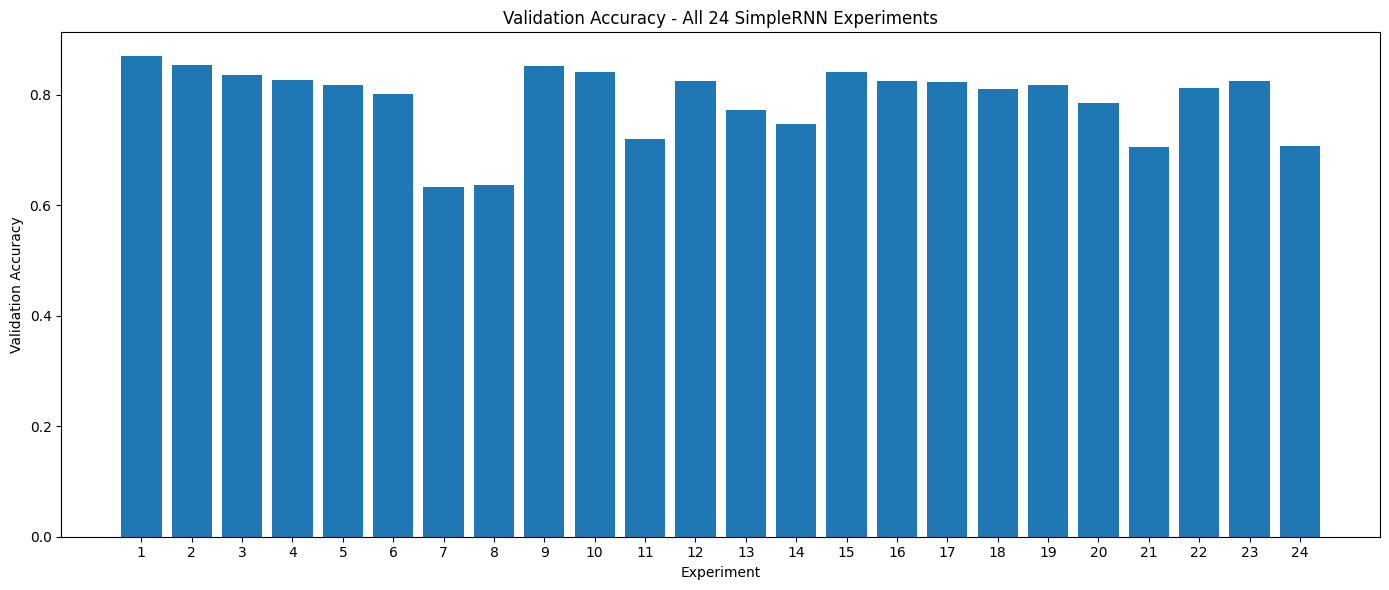

In [33]:
# ============================================================
# 20. VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(14, 6))

plt.bar(
    results_df["experiment"].astype(str),
    results_df["val_accuracy"]
)

plt.xlabel("Experiment")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy - All 24 SimpleRNN Experiments")

plt.xticks(
    results_df["experiment"].astype(str)
)

plt.tight_layout()
plt.show()

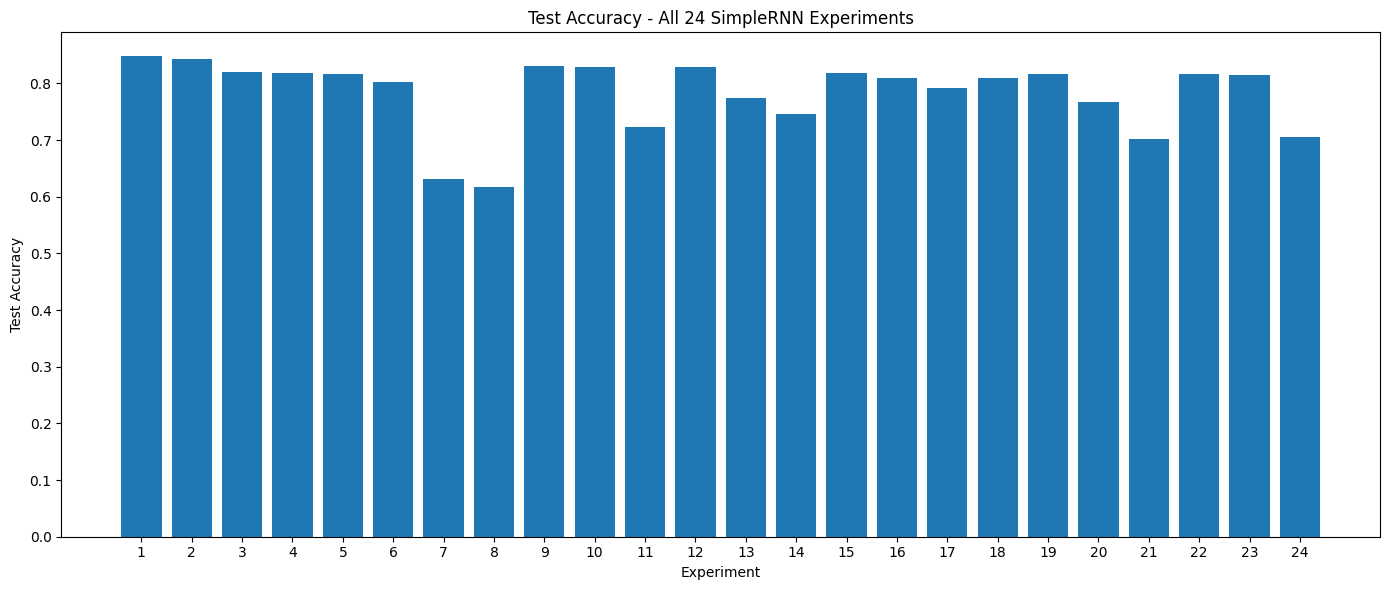

In [34]:
# ============================================================
# 21. TEST ACCURACY
# ============================================================

plt.figure(figsize=(14, 6))

plt.bar(
    results_df["experiment"].astype(str),
    results_df["test_accuracy"]
)

plt.xlabel("Experiment")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy - All 24 SimpleRNN Experiments")

plt.xticks(
    results_df["experiment"].astype(str)
)

plt.tight_layout()
plt.show()

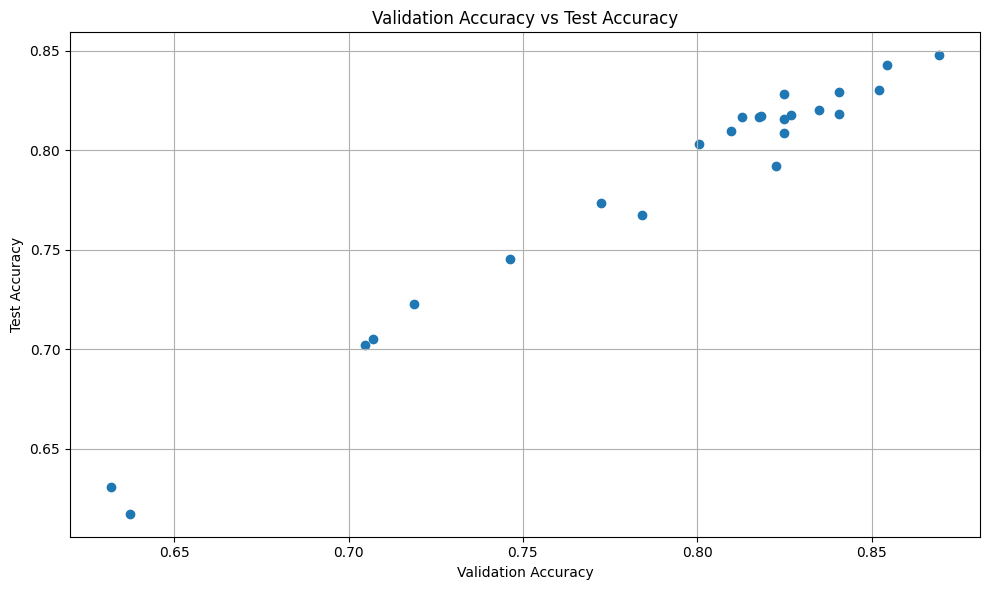

In [35]:
# ============================================================
# 22. VALIDATION VS TEST ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    results_df["val_accuracy"],
    results_df["test_accuracy"]
)

plt.xlabel("Validation Accuracy")
plt.ylabel("Test Accuracy")
plt.title("Validation Accuracy vs Test Accuracy")

plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# 23. RECREATE BEST MODEL
# ============================================================

best_max_len = int(best_config["max_len"])
best_rnn_units = int(best_config["rnn_units"])
best_activation = best_config["activation"]
best_dropout = float(best_config["dropout"])

print("Best model:")
print("-----------------------------")
print("max_len   :", best_max_len)
print("RNN units :", best_rnn_units)
print("activation:", best_activation)
print("dropout   :", best_dropout)

Best model:
-----------------------------
max_len   : 250
RNN units : 64
activation: relu
dropout   : 0.0


In [37]:
# ============================================================
# 24. PREPARE BEST MODEL DATA
# ============================================================

X_train_best = data[best_max_len]["X_train"]
X_val_best = data[best_max_len]["X_val"]
X_test_best = data[best_max_len]["X_test"]

In [38]:
# ============================================================
# 25. BUILD BEST MODEL
# ============================================================

tf.keras.backend.clear_session()

best_model = create_model(
    max_len=best_max_len,
    rnn_units=best_rnn_units,
    activation=best_activation,
    dropout_rate=best_dropout
)

best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# ============================================================
# 26. TRAIN BEST MODEL
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

best_history = best_model.fit(
    X_train_best,
    y_train_final,
    validation_data=(X_val_best, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.6862 - loss: 0.5756 - val_accuracy: 0.8100 - val_loss: 0.4312 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8331 - loss: 0.3727 - val_accuracy: 0.8080 - val_loss: 0.4386 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9003 - loss: 0.2460 - val_accuracy: 0.8562 - val_loss: 0.3745 - learning_rate: 5.0000e-04
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9269 - loss: 0.1859 - val_accuracy: 0.8512 - val_loss: 0.4088 - learning_rate: 5.0000e-04
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9531 - loss: 0.1302 - val_accuracy: 0.8506 - val_loss: 0.4555 - learning_rate: 2.5000e-04
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9654 - loss: 0.1025 - val_accuracy: 0.8534 - val_loss: 0.4537 - learning_rate: 1.2500e-04


In [40]:
# ============================================================
# 27. FINAL TEST EVALUATION
# ============================================================

final_test_loss, final_test_accuracy = best_model.evaluate(
    X_test_best,
    y_test,
    verbose=1
)

print("\nFINAL TEST RESULT")
print("=" * 50)
print("Test Loss     :", final_test_loss)
print("Test Accuracy :", final_test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8581 - loss: 0.3582

FINAL TEST RESULT
Test Loss     : 0.3581767976284027
Test Accuracy : 0.8581200242042542


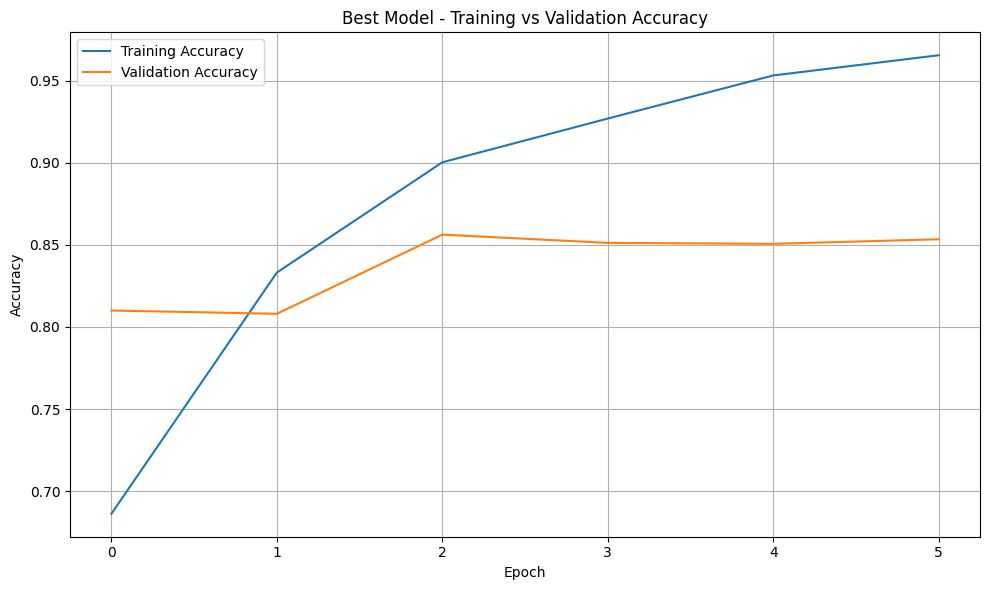

In [41]:
# ============================================================
# 28. TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    best_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    best_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Best Model - Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

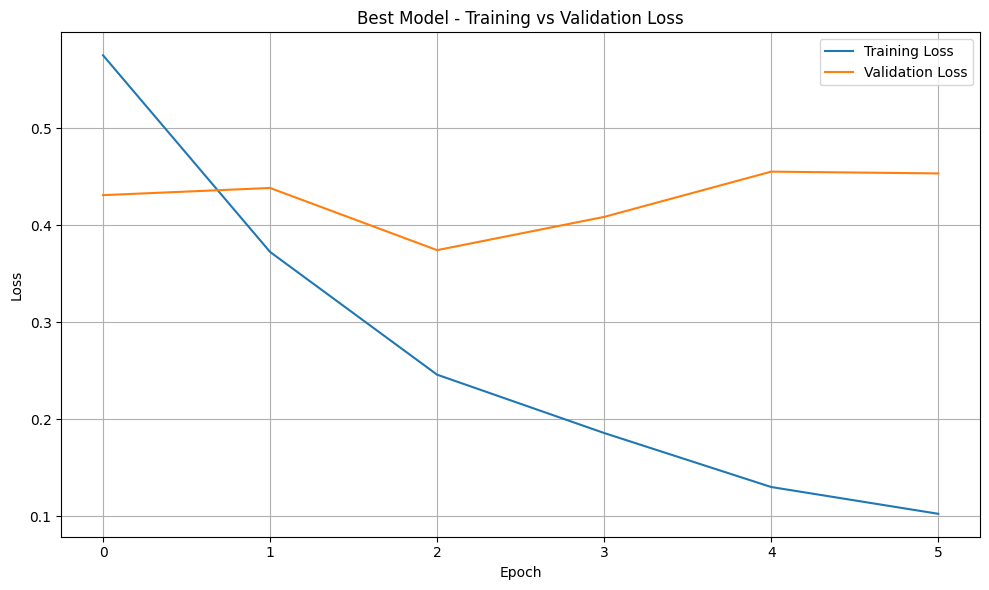

In [42]:
# ============================================================
# 29. TRAINING LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    best_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best Model - Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# 30. FINAL SUMMARY
# ============================================================

summary_columns = [
    "max_len",
    "rnn_units",
    "activation",
    "dropout",
    "best_epoch",
    "val_accuracy",
    "val_loss",
    "test_accuracy",
    "test_loss"
]

final_comparison = results_by_val[summary_columns]

display(final_comparison)

,max_len,rnn_units,activation,dropout,best_epoch,val_accuracy,val_loss,test_accuracy,test_loss
0,250,64,relu,0.0,5,0.8692,0.388666,0.84784,0.374858
1,250,64,relu,0.2,5,0.8544,0.381334,0.84284,0.377634
2,250,128,relu,0.5,8,0.8522,0.434217,0.83028,0.429701
3,250,128,tanh,0.0,6,0.8406,0.420858,0.82940,0.416137
4,500,64,relu,0.5,5,0.8406,0.433113,0.81824,0.429231
5,250,64,relu,0.5,5,0.8348,0.430401,0.82020,0.441358
6,250,64,tanh,0.0,3,0.8270,0.421870,0.81788,0.412176
7,250,128,tanh,0.5,4,0.8250,0.434175,0.82848,0.423036
8,500,64,tanh,0.0,3,0.8248,0.445624,0.80876,0.437152
9,500,128,tanh,0.2,5,0.8248,0.440914,0.81576,0.433097


In [47]:
# ============================================================
# FINAL MODEL
# ============================================================

import tensorflow as tf

max_features = 10000
max_len = 250
embedding_dim = 128
rnn_units = 64

model = tf.keras.Sequential([
    tf.keras.Input(shape=(max_len,)),

    tf.keras.layers.Embedding(
        input_dim=max_features,
        output_dim=embedding_dim
    ),

    tf.keras.layers.SimpleRNN(
        rnn_units,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# ============================================================
# TRAIN FINAL MODEL
# ============================================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

history = model.fit(
    X_train_best,
    y_train_final,
    validation_data=(X_val_best, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.7242 - loss: 0.5381 - val_accuracy: 0.8288 - val_loss: 0.3917 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8001 - loss: 0.4619 - val_accuracy: 0.8148 - val_loss: 0.4269 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8777 - loss: 0.2948 - val_accuracy: 0.8478 - val_loss: 0.3889 - learning_rate: 5.0000e-04
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9089 - loss: 0.2284 - val_accuracy: 0.8522 - val_loss: 0.3762 - learning_rate: 5.0000e-04
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9333 - loss: 0.1792 - val_accuracy: 0.8550 - val_loss: 0.3857 - learning_rate: 5.0000e-04
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9517 - loss: 0.1370 - val_accuracy: 0.8592 - val_loss: 0.3992 - learning_rate: 2.5000e-04
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 

In [49]:
# ============================================================
# FINAL EVALUATION
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test_best,
    y_test,
    verbose=1
)

print("\nFINAL MODEL")
print("=" * 50)
print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8476 - loss: 0.3784

FINAL MODEL
Test Loss     : 0.37838029861450195
Test Accuracy : 0.8475599884986877


In [50]:
# ============================================================
# SAVE MODEL
# ============================================================

model.save("model.keras")

print("\nSaved successfully:")
print("model.keras")


Saved successfully:
model.keras
